# PROJETO: PREDIÇÃO DE DIABETES - CETAM
**Disciplina:** Machine Learning | **Instrutora:** Erika Santos  
**Autores:** Erickson Carlos, Fernanda Sousa, Victor Matheus

## 1. Instalação de Bibliotecas e Carregamento dos Dados
Nesta etapa, instalamos e importamos as bibliotecas necessárias, além de fazer o download do dataset BRFSS2015 diretamente do Kaggle.

In [ ]:
!pip install -q kagglehub

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Configuração dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

print("--- 1. Baixando e Carregando o Conjunto de Dados do Kaggle ---")
# Baixa o dataset
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
file_path = os.path.join(path, "diabetes_binary_health_indicators_BRFSS2015.csv")

df = pd.read_csv(file_path)
print(f"Dataset carregado com sucesso! Total de Registros: {df.shape[0]} | Colunas: {df.shape[1]}")

--- 1. Baixando e Carregando o Conjunto de Dados do Kaggle ---
Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Dataset carregado com sucesso! Total de Registros: 253680 | Colunas: 22


## 2. Tradução das Variáveis
Renomeando as colunas originais do dataset do inglês para o português para facilitar a interpretação e a apresentação dos resultados.

In [ ]:
# 2. Tradução das Variáveis para o Português
traducao_colunas = {
    'Diabetes_binary': 'Diabetes_Binario',
    'HighBP': 'Pressao_Alta',
    'HighChol': 'Colesterol_Alto',
    'CholCheck': 'Exame_Colesterol_5Anos',
    'BMI': 'IMC',
    'Smoker': 'Fumante',
    'Stroke': 'AVC',
    'HeartDiseaseorAttack': 'Doenca_Cardiaca_ou_Infarto',
    'PhysActivity': 'Atividade_Fisica',
    'Fruits': 'Consumo_Frutas',
    'Veggies': 'Consumo_Vegetais',
    'HvyAlcoholConsump': 'Consumo_Elevado_Alcool',
    'AnyHealthcare': 'Plano_Saude',
    'NoDocbcCost': 'Deixou_Medico_Por_Custo',
    'GenHlth': 'Saude_Geral_1a5',
    'MentHlth': 'Dias_Saude_Mental_Ruim',
    'PhysHlth': 'Dias_Saude_Fisica_Ruim',
    'DiffWalk': 'Dificuldade_Caminar',
    'Sex': 'Sexo',
    'Age': 'Faixa_Etaria',
    'Education': 'Nivel_Escolaridade',
    'Income': 'Nivel_Renda'
}
df = df.rename(columns=traducao_colunas)
df

,Diabetes_Binario,Pressao_Alta,Colesterol_Alto,Exame_Colesterol_5Anos,IMC,Fumante,AVC,Doenca_Cardiaca_ou_Infarto,Atividade_Fisica,Consumo_Frutas,...,Plano_Saude,Deixou_Medico_Por_Custo,Saude_Geral_1a5,Dias_Saude_Mental_Ruim,Dias_Saude_Fisica_Ruim,Dificuldade_Caminar,Sexo,Faixa_Etaria,Nivel_Escolaridade,Nivel_Renda
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


## 3. Análise Exploratória de Dados (EDA)
Verificação do balanceamento da variável alvo (`Diabetes_Binario`) e geração do gráfico de distribuição dos pacientes.

In [ ]:
print("\n--- 2. Distribuição da Variável Alvo ---")
mapa_rotulos = {0.0: 'Sem Diabetes', 1.0: 'Com Diabetes/Pré'}
print(df['Diabetes_Binario'].map(mapa_rotulos).value_counts())


--- 2. Distribuição da Variável Alvo ---
Diabetes_Binario
Sem Diabetes        218334
Com Diabetes/Pré     35346
Name: count, dtype: int64


/tmp/ipykernel_3532/2172878505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['Diabetes_Binario'].map(mapa_rotulos), palette='viridis')


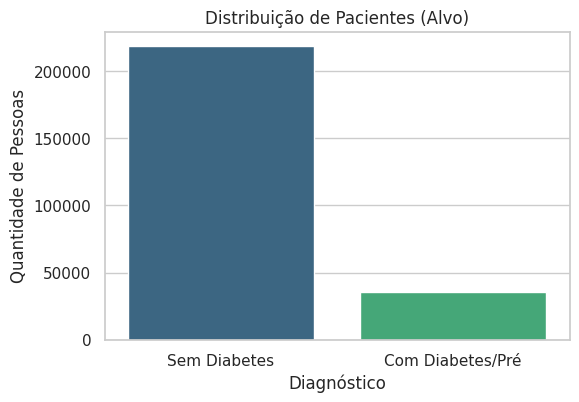

In [ ]:
# Gráfico da Distribuição da Variável Alvo
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=df['Diabetes_Binario'].map(mapa_rotulos), palette='viridis')
plt.title('Distribuição de Pacientes (Alvo)')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade de Pessoas')
plt.show()


## 4. Divisão dos Dados e Pré-processamento
Separação dos recursos ($X$) e do alvo ($y$), divisão em conjuntos de treino (80%) e teste (20%), além da padronização das variáveis com `StandardScaler`.

In [ ]:
print("\n--- 3. Preparando os Dados (Treino e Teste) ---")
SEED=42
X = df.drop('Diabetes_Binario', axis=1)
y = df['Diabetes_Binario']

# Separar em 80% treino e 20% teste com SEED=42 (Garante reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Padronização das Variáveis
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


--- 3. Preparando os Dados (Treino e Teste) ---


## 5. Treinamento dos Modelos
Treinamento dos dois modelos de aprendizado de máquina supervisionado:
1. **Regressão Logística**
2. **Random Forest (Floresta Aleatória)**

In [ ]:
# 5. Treinamento dos Modelos (Exigência: 2 Modelos)
print("\n--- 4. Treinando Modelo 1: Regressão Logística ---")
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- 5. Treinando Modelo 2: Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]


--- 4. Treinando Modelo 1: Regressão Logística ---

--- 5. Treinando Modelo 2: Random Forest ---


## 6. Avaliação e Comparação dos Modelos
Cálculo das métricas de Acurácia, AUC-ROC e relatórios detalhados de classificação para ambos os modelos.

In [ ]:
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("\n=======================================================")
print("             COMPARAÇÃO DOS MODELOS                    ")
print("=======================================================")
print(f"Regressão Logística -> Acurácia: {acc_lr*100:.2f}% | AUC-ROC: {auc_lr:.4f}")
print(f"Random Forest       -> Acurácia: {acc_rf*100:.2f}% | AUC-ROC: {auc_rf:.4f}")
print("=======================================================\n")

print("--- Relatório Detalhado: Regressão Logística ---")
print(classification_report(y_test, y_pred_lr, target_names=['Sem Diabetes', 'Com Diabetes']))

print("--- Relatório Detalhado: Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Sem Diabetes', 'Com Diabetes']))


             COMPARAÇÃO DOS MODELOS                    
Regressão Logística -> Acurácia: 86.21% | AUC-ROC: 0.8192
Random Forest       -> Acurácia: 85.94% | AUC-ROC: 0.7948

--- Relatório Detalhado: Regressão Logística ---
              precision    recall  f1-score   support

Sem Diabetes       0.88      0.98      0.92     43667
Com Diabetes       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736

--- Relatório Detalhado: Random Forest ---
              precision    recall  f1-score   support

Sem Diabetes       0.88      0.97      0.92     43667
Com Diabetes       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736



## 7. Matrizes de Confusão
Visualização comparativa das matrizes de confusão da Regressão Logística e do Random Forest.

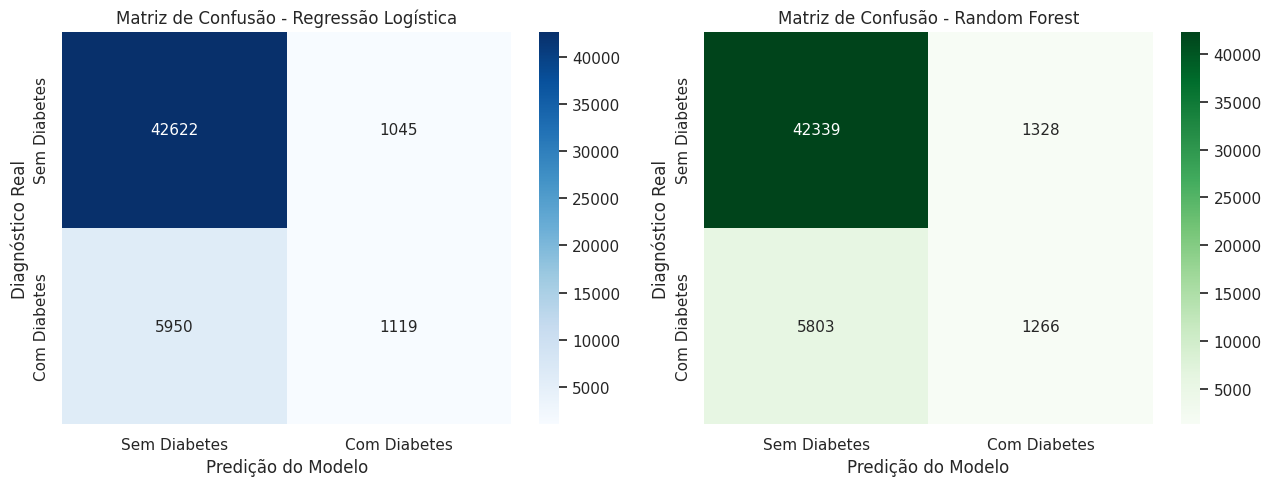

In [ ]:
# 7. Visualizações para o Banner (Matrizes de Confusão Lado a Lado)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sem Diabetes', 'Com Diabetes'], yticklabels=['Sem Diabetes', 'Com Diabetes'])
axes[0].set_title('Matriz de Confusão - Regressão Logística')
axes[0].set_xlabel('Predição do Modelo')
axes[0].set_ylabel('Diagnóstico Real')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Sem Diabetes', 'Com Diabetes'], yticklabels=['Sem Diabetes', 'Com Diabetes'])
axes[1].set_title('Matriz de Confusão - Random Forest')
axes[1].set_xlabel('Predição do Modelo')
axes[1].set_ylabel('Diagnóstico Real')

plt.tight_layout()
plt.show()

## 8. Importância das Variáveis (Feature Importance)
Gráfico destacando quais características do paciente têm maior relevância para a predição do diagnóstico segundo o Random Forest.

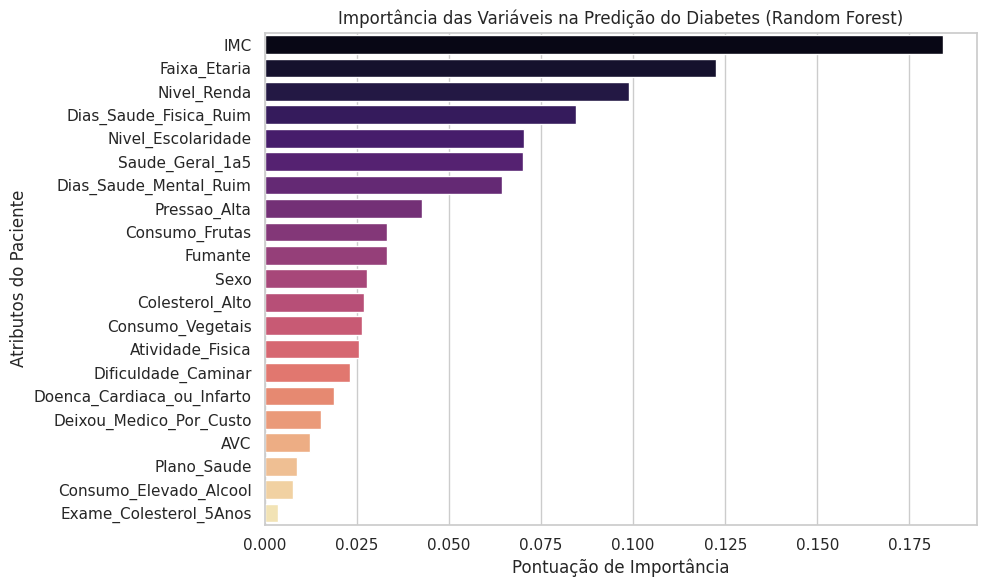

In [ ]:
# 8. Gráfico de Importância das Variáveis (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, hue=importances.index, legend=False, palette='magma')
plt.title('Importância das Variáveis na Predição do Diabetes (Random Forest)')
plt.xlabel('Pontuação de Importância')
plt.ylabel('Atributos do Paciente')
plt.tight_layout()
plt.show()